In [6]:
# Medical AI — Melanoma Detection (Group 12, merged pipeline)
## Does preprocessing shift a skin-cancer classifier's attention toward the lesion?

**This notebook is the merged, config-driven pipeline.** It combines the best parts of the team's separate notebooks:

- **Models**: ResNet18 transfer learning (+ SimpleConvNet baseline), label smoothing.
- **Preprocessing (the independent variable)**: hair removal, vignette/illumination correction, synthetic-hair augmentation.
- **Lesion masks**: robust k-means segmentation with a quality-control (QC) flag.
- **Attention metrics**: `cam_overlap` (how much Grad-CAM lands on the lesion) and `border_fraction` (vignette shortcut).
- **Rigor**: a multi-seed experiment harness that reports mean ± std.

### How to use it
Everything is driven by one `config` dict and a `CONDITIONS` table. To run the full study:
1. Run sections 0–7 once (definitions + precompute lesion masks).
2. Section 8 = a single interactive training run (for sanity checks / hero images).
3. **Section 9 = the actual experiment**: `{condition} × {seed} × {model}` → results table with error bars.
4. Section 10 = analysis figures (focus↔correctness, comparisons).

> **Note:** this file was assembled by merging code; run it top-to-bottom on Kaggle (GPU + the *medical-ai-with-test-set* dataset attached) to shake out any environment-specific issues before the big sweep.

SyntaxError: unterminated string literal (detected at line 4) (3008031008.py, line 4)

In [4]:
from IPython.display import FileLink
FileLink('runs_backup.zip')

/kaggle/working/runs_backup.zip

## 0. Environment setup

In [7]:
# !pip install pytorch-lightning wandb   # (already installed on Kaggle)
import os, glob
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage as ndi
from scipy.ndimage import rotate

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models_zoo
import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from functools import lru_cache
from tqdm.auto import tqdm                                   # progress bars
from scipy.stats import wilcoxon, mannwhitneyu, spearmanr      # NEW: statistics for Q1-Q3
try:
    import statsmodels.formula.api as smf
except Exception:
    smf = None            # Q3 logistic regression is skipped if statsmodels is unavailable

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); pl.seed_everything(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Seed set to 42


device: cuda


## 1. Configuration — the single source of truth

Every knob lives here. The experiment varies **`condition`** (preprocessing) and the training **seed**; everything else is held fixed so comparisons are clean.

In [8]:
# ============================================================================
# QUICK_CHECK: teammates flip this ON for a fast smoke run before the long study.
#   True  -> 1 epoch, ~20 masks, 1 seed, SEPARATE run cache (won't pollute the full run)
#   False -> full study (7 epochs, all masks, 5 seeds)
QUICK_CHECK = False
# ============================================================================


# All outputs for THIS run go under one clearly-named folder, so full-run data stays separate:
RUN_TAG     = 'quick_check' if QUICK_CHECK else 'full_run'
OUTPUT_ROOT = f'/kaggle/working/{RUN_TAG}'
os.makedirs(OUTPUT_ROOT, exist_ok=True)
print('all outputs ->', OUTPUT_ROOT)

# ---- dataset paths (the released test-set version) ----
DATA_DIR = '/kaggle/input/datasets/matthancaan/medical-ai-with-test-set/classification/'

config = {
    # data
    'train_data_dir' : os.path.join(DATA_DIR, 'train'),
    'val_data_dir'   : os.path.join(DATA_DIR, 'val'),
    'test_data_dir'  : os.path.join(DATA_DIR, 'test'),
    'batch_size'     : 32,

    # model + optimisation
    'model_name'     : 'resnet18',       # 'resnet18' | 'resnet34' | 'custom_convnet'
    'optimizer_name' : 'adam',
    'optimizer_lr'   : 1e-3,
    'max_epochs'     : 1 if QUICK_CHECK else 15,
    'label_smoothing': 0.1,
    'pretrained_normalization': True,    # ImageNet mean/std — MUST be True for ResNet, False for SimpleConvNet

    # preprocessing condition (the independent variable) — see CONDITIONS below
    'condition'      : 'none',           # 'none' | 'hair_removal' | 'vignette_correction' | 'hair_augmentation'

    # W&B (single interactive runs only; the sweep disables logging)
    'wandb_entity'   : 'group12-melanoma-detection',
    'wandb_project'  : 'melanoma-classification',
    'run_name'       : 'Final2',
    'bin'            : 'models/',
}

# A "condition" expands into: which preprocessing is applied to EVERY image (train+val+test),
# and how often synthetic hair is added during TRAINING only.
CONDITIONS = {
    # preprocess = deterministic op on EVERY image (train+val+test)
    # augment    = stochastic op added during TRAINING only (evaluate on RAW images)
    'none'                  : dict(preprocess='none',                augment=None,       aug_prob=0.0),
    'hair_removal'          : dict(preprocess='hair_removal',        augment=None,       aug_prob=0.0),
    'vignette_correction'   : dict(preprocess='vignette_correction', augment=None,       aug_prob=0.0),
    'hair_augmentation'     : dict(preprocess='none',                augment='hair',     aug_prob=0.5),
    'vignette_augmentation' : dict(preprocess='none',                augment='vignette', aug_prob=0.5),
    'both_augmentation'     : dict(preprocess='none',                augment='both',     aug_prob=0.5),
}

def apply_condition(cfg, condition):
    """Write the condition's preprocess mode + augmentation into a config dict."""
    cfg = dict(cfg); c = CONDITIONS[condition]
    cfg['condition']  = condition
    cfg['preprocess'] = c['preprocess']
    cfg['augment']    = c['augment']
    cfg['aug_prob']   = c['aug_prob']
    return cfg

config = apply_condition(config, config['condition'])

all outputs -> /kaggle/working/full_run


## 2. Preprocessing functions (the independent variable)

Three image operations, all working on an HWC uint8 RGB image:
- **`remove_hair`** — detects thin dark/light hairs (black-hat + top-hat) and inpaints them.
- **`correct_vignette`** — removes the dermoscope's dark-corner vignette + radial illumination fall-off (the shortcut we found). Uses `field_of_view` + `flatten_illumination`.
- **`preprocess_image`** — the dispatcher used by the dataset. These same helpers are reused by the lesion-mask pipeline in section 6.

In [9]:
def remove_hair(image, kernel_size=9, thresh=25):
    """Hair removal (DullRazor, team-tuned): black-hat highlights dark thin hairs, then inpaint.
       image: HWC uint8 RGB. Returns (inpainted_rgb, hair_mask). (tuned: kernel 9, thresh 25)"""
    img = np.ascontiguousarray(np.uint8(image))                       # cv2 needs a C-contiguous uint8 array
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, thresh, 255, cv2.THRESH_BINARY)
    inpainted = cv2.inpaint(img, hair_mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return inpainted, hair_mask


def field_of_view(rgb, rel_thresh=0.60, erode_frac=0.05, corner_frac=0.08):
    """Dermoscope aperture: dark regions that reach into the image CORNERS are outside the
       field of view (vignette). Dark regions that only touch an edge (a big lesion) are kept."""
    h, w = rgb.shape[:2]
    L = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)[..., 0].astype(np.float32)
    ref = np.percentile(L, 75)
    dark = (L < rel_thresh * ref).astype(np.uint8)
    dark = cv2.morphologyEx(dark, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    lab, n = ndi.label(dark)
    if n == 0:
        return np.ones((h, w), bool)
    c = max(2, int(corner_frac * min(h, w)))
    corner_ids = []
    for cy, cx in ((slice(0, c), slice(0, c)), (slice(0, c), slice(-c, None)),
                   (slice(-c, None), slice(0, c)), (slice(-c, None), slice(-c, None))):
        ids, cnt = np.unique(lab[cy, cx], return_counts=True)
        corner_ids += [i for i, k in zip(ids, cnt) if i > 0 and k > 0.5 * c * c]
    if not corner_ids:
        return np.ones((h, w), bool)
    outside = np.isin(lab, corner_ids)
    r = max(1, int(erode_frac * min(h, w)))
    return cv2.erode((~outside).astype(np.uint8),
                     cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1,) * 2)).astype(bool)


def flatten_illumination(ch, fov, n_iter=4, start_pct=50, n_sigma=2.0):
    """Robust quadratic fit of the skin background, then subtract it (corrects vignetting /
       radial fall-off). Fit ignores the lesion so it is not pulled down."""
    h, w = ch.shape
    yy, xx = np.mgrid[:h, :w].astype(np.float32)
    yy = (yy - h / 2) / h; xx = (xx - w / 2) / w
    A = np.stack([np.ones_like(xx), xx, yy, xx * xx, yy * yy, xx * yy], -1)
    use = fov & (ch >= np.percentile(ch[fov], start_pct))
    bg = np.zeros_like(ch)
    for _ in range(n_iter):
        if use.sum() < 50:
            break
        coef, *_ = np.linalg.lstsq(A[use], ch[use], rcond=None)
        bg = A @ coef
        res = ch - bg
        sig = 1.4826 * np.median(np.abs(res[use] - np.median(res[use]))) + 1e-6
        use = fov & (np.abs(res) < n_sigma * sig)
    return ch - bg + np.median(bg[use]) if use.sum() >= 50 else ch


def correct_vignette(rgb_u8):
    """Illumination-flatten the L channel and blank the dark out-of-FOV corners,
       removing the vignette cue the model was exploiting."""
    fov = field_of_view(rgb_u8)
    lab = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2LAB).astype(np.float32)
    lab[..., 0] = np.clip(flatten_illumination(lab[..., 0], fov), 0, 255)
    out = cv2.cvtColor(np.clip(lab, 0, 255).astype(np.uint8), cv2.COLOR_LAB2RGB)
    if fov.any() and (~fov).any():                       # paint corners with mean skin colour
        out[~fov] = out[fov].reshape(-1, 3).mean(0).astype(np.uint8)
    return out


def preprocess_image(rgb_u8, mode):
    """Deterministic preprocessing applied to EVERY image (train/val/test)."""
    if mode == 'hair_removal':
        return remove_hair(rgb_u8)[0]
    if mode == 'vignette_correction':
        return correct_vignette(rgb_u8)
    return rgb_u8                                          # 'none'


def load_raw_uint8(path):
    """Load a .nii dermoscopy image as an HWC uint8 RGB array (single source of truth)."""
    raw = nib.load(path).get_fdata()
    img = np.uint8(255 * (raw - raw.min()) / (raw.max() - raw.min() + 1e-8))
    return np.ascontiguousarray(img)          # cv2 (drawContours/inpaint) needs C-contiguous arrays

### Augmentation (training only)

In [10]:
def random_flip_rotate(image):
    """Geometric augmentation held constant across ALL conditions (so it never confounds)."""
    if np.random.rand() < 0.5: image = np.fliplr(image).copy()
    if np.random.rand() < 0.5: image = np.flipud(image).copy()
    if np.random.rand() < 0.5:
        image = rotate(image, np.random.uniform(-20, 20), axes=(0, 1), reshape=False, mode='reflect')
    return image


def add_synthetic_hair(image, n_hairs=None):
    """Draw random dark hair-like lines. Used only in the 'hair_augmentation' condition."""
    img = np.uint8(image).copy(); h, w = img.shape[:2]
    n_hairs = n_hairs or np.random.randint(3, 8)
    for _ in range(n_hairs):
        x1, y1 = np.random.randint(0, w), np.random.randint(0, h)
        x2, y2 = x1 + np.random.randint(-60, 60), y1 + np.random.randint(-60, 60)
        col = int(np.random.randint(0, 60))
        cv2.line(img, (x1, y1), (x2, y2), (col, col, col), np.random.randint(1, 2), cv2.LINE_AA)
    return img


def add_synthetic_vignette(image, strength=None, radius=None):
    """Darken the corners radially to mimic the dermoscope vignette (train-time augmentation).
       Random strength/radius so it decorrelates the vignette cue from the label."""
    img = np.uint8(image).astype(np.float32); h, w = img.shape[:2]
    strength = np.random.uniform(0.4, 0.9) if strength is None else strength
    radius   = np.random.uniform(0.6, 0.9) if radius   is None else radius
    yy, xx = np.mgrid[:h, :w]
    d = np.sqrt(((yy - h / 2) / (h / 2)) ** 2 + ((xx - w / 2) / (w / 2)) ** 2)   # 0 centre -> ~1.4 corner
    fall = np.clip((d - radius) / (d.max() - radius + 1e-6), 0, 1)
    vig = 1 - strength * fall
    return np.clip(img * vig[..., None], 0, 255).astype(np.uint8)


def add_both(image):
    return add_synthetic_vignette(add_synthetic_hair(image))


# maps a condition's `augment` name to the function applied during training
AUGMENTERS = {'hair': add_synthetic_hair, 'vignette': add_synthetic_vignette, 'both': add_both}


class Random_Transform(object):
    """Applies an augmentation function to a sample with probability p (training only)."""
    def __init__(self, probability, aug_fn):
        assert 0 < probability <= 1
        self.probability = probability
        self.aug_fn = aug_fn
    def __call__(self, sample):
        if float(torch.rand(1, dtype=torch.float64)) < self.probability:
            sample = self.aug_fn(sample)
        return np.ascontiguousarray(sample)

### Preprocessing sanity check
Shows a few images as **raw vs hair-removed vs vignette-corrected**, so you can confirm the two preprocessing steps actually do the right thing before running the full sweep. *(Needs the dataset attached.)*

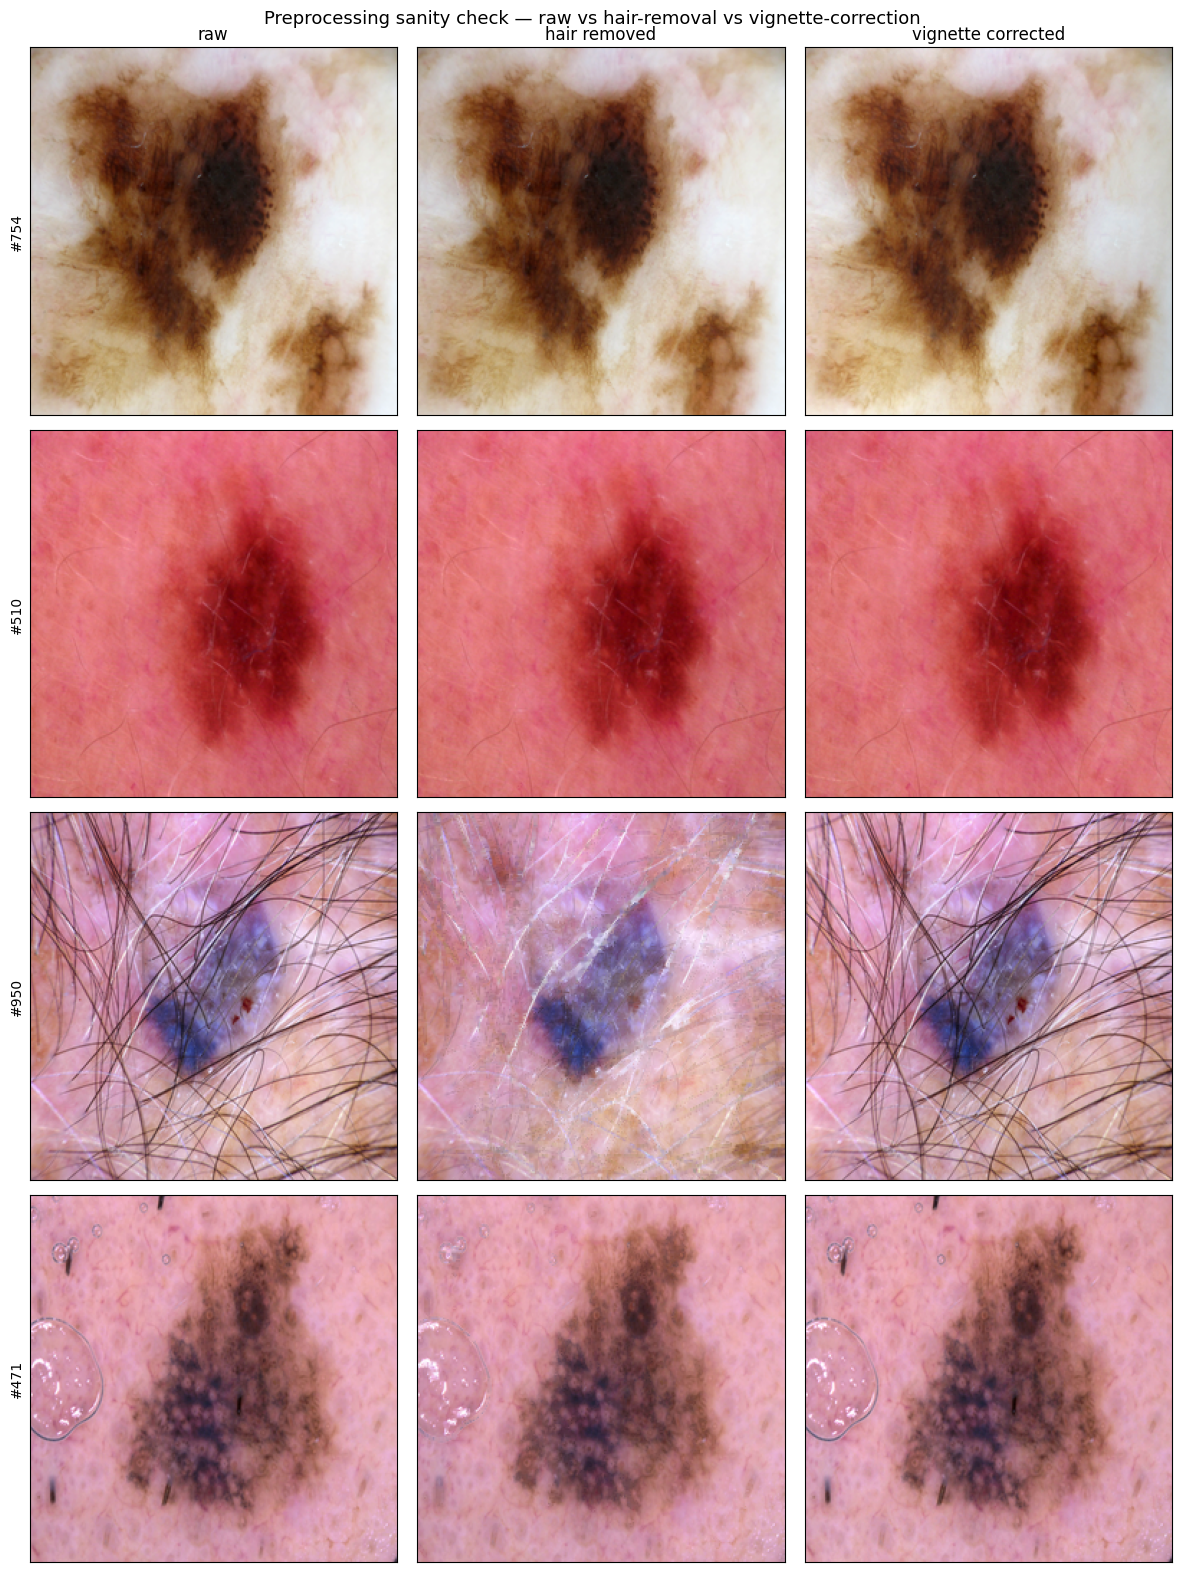

In [11]:
def show_preprocessing_examples(split='train', n=4, seed=1):
    files = sorted(glob.glob(os.path.join(config[f'{split}_data_dir'], 'img*.nii')))
    idxs  = np.random.default_rng(seed).choice(len(files), min(n, len(files)), replace=False)
    modes = [('raw', 'none'), ('hair removed', 'hair_removal'), ('vignette corrected', 'vignette_correction')]
    fig, ax = plt.subplots(len(idxs), 3, figsize=(12, 4 * len(idxs))); ax = np.atleast_2d(ax)
    for row, idx in enumerate(idxs):
        raw = load_raw_uint8(files[int(idx)])
        for col, (title, mode) in enumerate(modes):
            ax[row, col].imshow(preprocess_image(raw, mode))
            if row == 0: ax[row, col].set_title(title, fontsize=12)
            ax[row, col].set_xticks([]); ax[row, col].set_yticks([])
        ax[row, 0].set_ylabel(f'#{int(idx)}', fontsize=10)
    plt.suptitle('Preprocessing sanity check — raw vs hair-removal vs vignette-correction', fontsize=13)
    plt.tight_layout(); plt.show()

show_preprocessing_examples('train', 4)

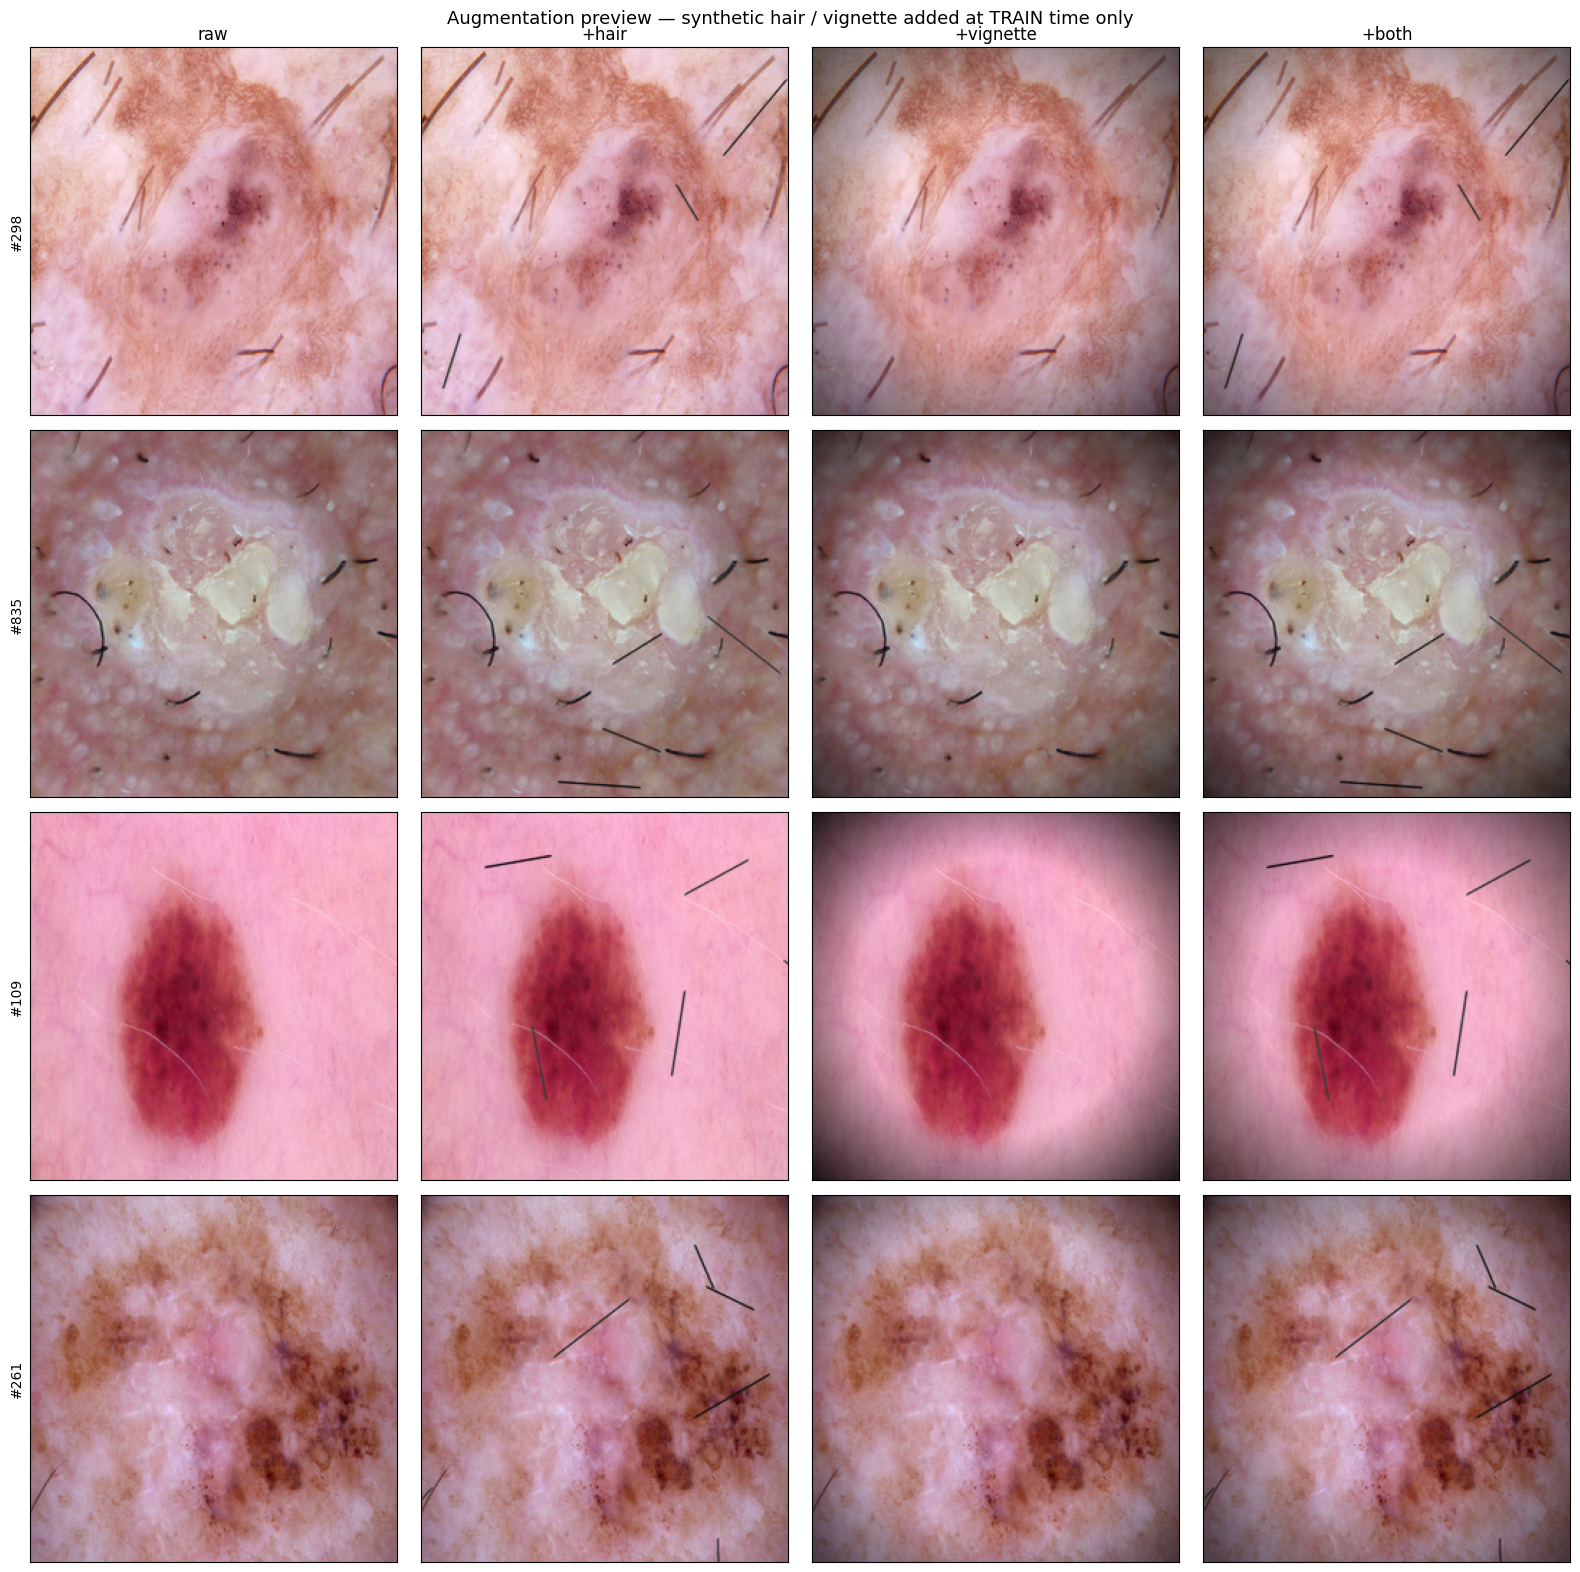

In [12]:
# --- augmentation preview: raw vs +synthetic hair vs +synthetic vignette ---
def show_augmentation_examples(split='train', n=4, seed=2):
    files = sorted(glob.glob(os.path.join(config[f'{split}_data_dir'], 'img*.nii')))
    idxs  = np.random.default_rng(seed).choice(len(files), min(n, len(files)), replace=False)
    cols  = [('raw', lambda im: im), ('+hair', add_synthetic_hair),
             ('+vignette', add_synthetic_vignette), ('+both', add_both)]
    fig, ax = plt.subplots(len(idxs), len(cols), figsize=(4*len(cols), 4*len(idxs))); ax = np.atleast_2d(ax)
    for row, idx in enumerate(idxs):
        raw = load_raw_uint8(files[int(idx)])
        for col, (title, fn) in enumerate(cols):
            np.random.seed(seed + row)          # fix randomness so the panels are comparable
            ax[row, col].imshow(fn(raw))
            if row == 0: ax[row, col].set_title(title, fontsize=12)
            ax[row, col].set_xticks([]); ax[row, col].set_yticks([])
        ax[row, 0].set_ylabel(f'#{int(idx)}', fontsize=10)
    plt.suptitle('Augmentation preview — synthetic hair / vignette added at TRAIN time only', fontsize=13)
    plt.tight_layout(); plt.show()

show_augmentation_examples('train', 4)

## 3. Dataset + DataModule

In [13]:
class Scan_Dataset(Dataset):
    """Loads a .nii image, applies the deterministic preprocessing for the current condition,
       reads the label from the filename, then applies the (augmentation + tensor) transform."""
    def __init__(self, data_dir, transform=False, preprocess_mode='none'):
        self.transform = transform
        self.preprocess_mode = preprocess_mode
        self.data_list = sorted(glob.glob(os.path.join(data_dir, 'img*.nii')))

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        if torch.is_tensor(idx): idx = idx.tolist()
        name = self.data_list[idx]
        img = load_raw_uint8(name)                        # HWC uint8 RGB
        img = preprocess_image(img, self.preprocess_mode) # deterministic preprocessing
        label = torch.tensor(int(name.split('.')[0][-1]))
        if self.transform:
            img = self.transform(img)
        return img, label


class Scan_DataModule(pl.LightningDataModule):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.batch_size = config['batch_size']
        self.preprocess = config.get('preprocess', 'none')

        to_tensor = transforms.Lambda(lambda x: torch.from_numpy(np.ascontiguousarray(x)).permute(2, 0, 1).float() / 255.0)
        train_steps = [transforms.Lambda(random_flip_rotate)]         # geometric aug (all conditions)
        aug_name = config.get('augment')
        if aug_name and config.get('aug_prob', 0.0) > 0:              # artifact augmentation (that condition only)
            train_steps.insert(0, Random_Transform(config['aug_prob'], AUGMENTERS[aug_name]))
        train_steps.append(to_tensor)
        val_steps = [to_tensor]
        if config.get('pretrained_normalization', False):             # ImageNet norm for ResNet
            norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            train_steps.append(norm); val_steps.append(norm)
        self.train_transforms = transforms.Compose(train_steps)
        self.val_transforms   = transforms.Compose(val_steps)

    def setup(self, stage=None):
        p = self.preprocess
        # NOTE: preprocessing is applied to ALL splits (this is the fix — the old code never passed the flag)
        self.train_dataset = Scan_Dataset(self.config['train_data_dir'], self.train_transforms, preprocess_mode=p)
        self.val_dataset   = Scan_Dataset(self.config['val_data_dir'],   self.val_transforms,   preprocess_mode=p)
        self.test_dataset  = Scan_Dataset(self.config['test_data_dir'],  self.val_transforms,   preprocess_mode=p)

    def train_dataloader(self): return DataLoader(self.train_dataset, batch_size=self.batch_size, num_workers=3, shuffle=True)
    def val_dataloader(self):   return DataLoader(self.val_dataset,   batch_size=self.batch_size, num_workers=3)
    def test_dataloader(self):  return DataLoader(self.test_dataset,  batch_size=self.batch_size, num_workers=3)

## 4. Models

In [14]:
class SimpleConvNet(nn.Module):
    """Baseline tiny CNN (from the scaffold). Weak on purpose — the comparison point."""
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),  nn.BatchNorm2d(8),  nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2, 2))
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)), nn.Flatten(),
            nn.Linear(4 * 4 * 16, 60), nn.ReLU(), nn.Linear(60, 1))
    def forward(self, x):
        return self.classifier(self.layers(x))


class ResNet18Classifier(nn.Module):
    """ImageNet-pretrained ResNet18, early layers frozen, 1-logit head."""
    def __init__(self, freeze_until_layer=7):
        super().__init__()
        backbone = models_zoo.resnet18(weights=models_zoo.ResNet18_Weights.IMAGENET1K_V1)
        for layer in list(backbone.children())[:freeze_until_layer]:
            for p in layer.parameters(): p.requires_grad = False
        backbone.fc = nn.Linear(backbone.fc.in_features, 1)
        self.model = backbone
        self.n_frozen = freeze_until_layer
    def train(self, mode=True):                  # FIX: frozen layers stay in eval mode, so their BatchNorm stats don't change
        super().train(mode)
        for layer in list(self.model.children())[:self.n_frozen]: layer.eval()
        return self
    def forward(self, x):
        return self.model(x)


class ResNet34Classifier(nn.Module):
    def __init__(self, freeze_until_layer=7):
        super().__init__()
        backbone = models_zoo.resnet34(weights=models_zoo.ResNet34_Weights.IMAGENET1K_V1)
        for layer in list(backbone.children())[:freeze_until_layer]:
            for p in layer.parameters(): p.requires_grad = False
        backbone.fc = nn.Linear(backbone.fc.in_features, 1)
        self.model = backbone
        self.n_frozen = freeze_until_layer
    def train(self, mode=True):                  # FIX: frozen layers stay in eval mode, so their BatchNorm stats don't change
        super().train(mode)
        for layer in list(self.model.children())[:self.n_frozen]: layer.eval()
        return self
    def forward(self, x):
        return self.model(x)


models     = {'custom_convnet': SimpleConvNet,
              'resnet18': ResNet18Classifier,
              'resnet34': ResNet34Classifier}
optimizers = {'adam': torch.optim.Adam, 'sgd': torch.optim.SGD}


def smooth_labels(y, smoothing=0.0):
    return y * (1 - smoothing) + 0.5 * smoothing

In [15]:
class Classifier(pl.LightningModule):
    """Lightning wrapper. Takes config explicitly (no global state), uses per-instance metrics,
       and applies label smoothing in the loss."""
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.model_name = config['model_name']
        assert self.model_name in models, f'Unknown model {self.model_name}'
        self.model = models[self.model_name]().to(device)
        self.optimizer_name = config['optimizer_name']
        self.lr = config['optimizer_lr']
        self.metrics = {'acc': torchmetrics.Accuracy(task="binary").to(device),
                        'f1': torchmetrics.F1Score(task="binary").to(device),
                        'precision': torchmetrics.Precision(task="binary").to(device),
                        'recall': torchmetrics.Recall(task="binary").to(device)}

    def step(self, batch, nn_set):
        X, y = batch
        X, y = X.float().to(device), y.to(device)
        y_hat = self.model(X).squeeze(1)
        y_prob = torch.sigmoid(y_hat)
        smoothing = self.config.get('label_smoothing', 0.0)
        loss = F.binary_cross_entropy_with_logits(y_hat, smooth_labels(y.float(), smoothing))
        self.log(f'{nn_set}_loss', loss, on_step=False, on_epoch=True)
        for name, fn in self.metrics.items():
            self.log(f'{nn_set}_{name}', fn(y_prob, y), on_step=False, on_epoch=True)
        return loss

    def training_step(self, b, i):   return self.step(b, "train")
    def validation_step(self, b, i): return self.step(b, "val")
    def test_step(self, b, i):       return self.step(b, "test")
    def forward(self, X):            return self.model(X)
    def configure_optimizers(self):  return optimizers[self.optimizer_name](self.parameters(), lr=self.lr)

## 5. Grad-CAM

In [16]:
class GradCAMClassification:
    """Grad-CAM for a 1-logit binary model. Hooks a target conv layer, back-props the
       melanoma logit, and returns a [0,1] heatmap + the predicted probability."""
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None; self.gradients = None
        self.fwd = target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'activations', o))
        self.bwd = target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0]))
    def remove_hooks(self):
        self.fwd.remove(); self.bwd.remove()
    def compute_cam(self, x, sign=1):              # NEW: sign=-1 explains the benign decision (-logit)
        self.model.zero_grad()
        x = x.clone().requires_grad_(True)
        logits = self.model(x).squeeze(1)
        prob = torch.sigmoid(logits)
        (sign * logits).sum().backward()
        w = self.gradients.mean(dim=(2, 3), keepdim=True)          # GAP over gradients
        cam = F.relu((w * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 0: cam /= cam.max()
        return cam, prob.item()


layer_number = 6   # SimpleConvNet: ReLU after the 2nd conv block

def get_target_layer(classifier):
    """Return the Grad-CAM target layer for whichever backbone is in use."""
    inner = classifier.model
    if isinstance(inner, SimpleConvNet):
        return inner.layers[layer_number]
    if isinstance(inner, (ResNet18Classifier, ResNet34Classifier)):
        return inner.model.layer4[-1]          # last residual block
    raise ValueError(f'No target layer for {type(inner)}')

## 6. Lesion masks (k-means + QC)

We have no ground-truth masks, so we build them without training: hair removal → field-of-view → k-means on CIELAB colour + position → keep the large central blob → clean up. Each mask gets a **`qc_ok`** flag (from stability across seeds, plausible area, contrast, and not touching the edge). **Masks that fail QC are excluded from the attention statistics.**

Masks are computed on the **raw** image (lesion location is the same before/after preprocessing), saved once, and reused by every condition/seed.

In [17]:
def to_uint8_rgb(img):
    if hasattr(img, 'detach'): img = img.detach().cpu().numpy()
    img = np.asarray(img, np.float32)
    if img.ndim == 3 and img.shape[0] == 3 and img.shape[-1] != 3:
        img = np.transpose(img, (1, 2, 0))
    if img.max() <= 1.0: img = img * 255.0
    return np.ascontiguousarray(np.clip(img, 0, 255).astype(np.uint8))


def dice(a, b):
    s = a.sum() + b.sum()
    return 1.0 if s == 0 else 2.0 * (a & b).sum() / s


def pick_component(mask, contrast_map):
    """Keep the blob with the best area x contrast x centrality score."""
    lab, n = ndi.label(mask)
    if n == 0: return mask
    h, w = mask.shape; cy, cx = (h - 1) / 2, (w - 1) / 2; half_diag = np.hypot(cy, cx)
    best, best_score = 0, -np.inf
    for i, sl in enumerate(ndi.find_objects(lab), start=1):
        comp = lab[sl] == i; yy, xx = np.nonzero(comp)
        d = np.hypot(yy.mean() + sl[0].start - cy, xx.mean() + sl[1].start - cx)
        c = max(contrast_map[sl][comp].mean(), 1e-3)
        score = len(yy) * c * (1.0 - 0.8 * d / half_diag)
        if score > best_score: best, best_score = i, score
    return lab == best


def merge_nearby(all_blobs, main, gap_frac=0.06):
    if not main.any(): return main
    h, w = main.shape; r = max(1, int(gap_frac * min(h, w)))
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1,) * 2)
    near = cv2.dilate(main.astype(np.uint8), se).astype(bool)
    lab, n = ndi.label(all_blobs); keep = np.unique(lab[near & all_blobs]); keep = keep[keep > 0]
    m = main | np.isin(lab, keep)
    m = cv2.morphologyEx(m.astype(np.uint8), cv2.MORPH_CLOSE, se).astype(bool)
    return ndi.binary_fill_holes(m)


def lesion_features(clean, fov):
    lab = cv2.cvtColor(clean, cv2.COLOR_RGB2LAB).astype(np.float32)
    L = flatten_illumination(lab[..., 0], fov)
    a = lab[..., 1] - 128; b = lab[..., 2] - 128
    brown = b - 0.5 * a                       # pigment; red skin (erythema) is not counted as lesion
    return L, a, b, brown


def kmeans_mask(clean, fov, k=4, spatial_weight=0.3, seed=0, min_dL=6.0, min_dE=9.0,
                smooth_frac=0.02, merge_gap=0.03, noise_mult=3.0):
    h, w = fov.shape
    L, a, b, brown = lesion_features(clean, fov)
    s = max(0.5, smooth_frac * min(h, w))
    L, a, brown = (cv2.GaussianBlur(x.astype(np.float32), (0, 0), s) for x in (L, a, brown))
    yy, xx = np.mgrid[:h, :w].astype(np.float32)
    feats = np.dstack([L, brown, 0.5 * a, yy, xx]); X = feats[fov]
    sd = X.std(0) + 1e-6; sd[:3] = X[:, :3].std(0).max()
    X = (X - X.mean(0)) / sd; X[:, 3:] *= spatial_weight
    cv2.setRNGSeed(seed)
    crit = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 0.2)
    _, lbl, _ = cv2.kmeans(X.astype(np.float32), k, None, crit, 5, cv2.KMEANS_PP_CENTERS)
    labels = np.full((h, w), -1, int); labels[fov] = lbl.ravel()
    stats = [( (labels == c).mean(), L[labels == c].mean(), brown[labels == c].mean() ) for c in range(k)]
    big = [c for c in range(k) if stats[c][0] > 0.10] or list(range(k))
    skin = max(big, key=lambda c: stats[c][1] - stats[c][2])
    sL, sB = stats[skin][1], stats[skin][2]; sk = labels == skin
    min_dE = max(min_dE, noise_mult * float(np.hypot(L[sk].std(), brown[sk].std())))
    lesion = [c for c in range(k) if c != skin and (sL - stats[c][1]) > min_dL
              and np.hypot(sL - stats[c][1], stats[c][2] - sB) > min_dE]
    m = fov & np.isin(labels, lesion)
    kk = max(3, int(round(0.02 * min(h, w))) | 1)
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kk, kk))
    m = cv2.morphologyEx(m.astype(np.uint8), cv2.MORPH_OPEN, se)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3 * kk,) * 2)).astype(bool)
    contrast = np.clip(sL - L, 0, None) + np.clip(brown - sB, 0, None)
    m = merge_nearby(m & fov, pick_component(m & fov, contrast), gap_frac=merge_gap)
    return m, {'contrast': float(contrast[m].mean()) if m.any() else 0.0}


def make_lesion_mask(img, min_area=0.005, max_area=0.85, min_stability=0.70,
                     min_contrast=8.0, max_edge=0.5):
    """Returns (bool mask, qc dict). qc['qc_ok'] tells you whether to trust it."""
    rgb = to_uint8_rgb(img)
    clean = remove_hair(rgb)[0]
    fov = field_of_view(clean)
    clean = cv2.GaussianBlur(clean, (5, 5), 0)
    mask, info = kmeans_mask(clean, fov)
    alts = [kmeans_mask(clean, fov, k=k, seed=sd)[0] for k, sd in ((3, 1), (5, 2), (4, 3), (4, 4))]
    stability = float(np.median([dice(mask, a) for a in alts]))
    area = mask.mean()
    edge = np.concatenate([mask[0], mask[-1], mask[:, 0], mask[:, -1]]).mean()
    qc = {'area_frac': area, 'stability': stability, 'contrast': info['contrast'], 'edge_touch': edge,
          'qc_ok': bool(min_area <= area <= max_area and stability >= min_stability
                        and info['contrast'] >= min_contrast and edge < max_edge)}
    return mask, qc

### Precompute + save masks (run once per split)

In [18]:
# separate quick/full mask caches so a QUICK_CHECK=True run (20 masks) can't pollute the full run
MASK_DIR = os.path.join(OUTPUT_ROOT, 'lesion_masks')
MASK_SPLITS = ['test']                       # only the evaluation split needs masks

# OPTIONAL: reuse masks you previously saved as a Kaggle Dataset (skips the slow recompute).
# Set this to the attached folder that contains the per-split mask files, then it is copied in.
MASK_CACHE_INPUT = "/kaggle/input/datasets/davidborensztajn/group12-lesion-masks"                       # e.g. '/kaggle/input/group12-lesion-masks/lesion_masks'
if MASK_CACHE_INPUT and os.path.isdir(MASK_CACHE_INPUT):
    import shutil; shutil.copytree(MASK_CACHE_INPUT, MASK_DIR, dirs_exist_ok=True)
    print('reused cached masks from', MASK_CACHE_INPUT)

def precompute_masks(splits=MASK_SPLITS):
    qc_tables = {}
    for split in splits:
        ds = Scan_Dataset(config[f'{split}_data_dir'])   # raw images (preprocess_mode='none')
        out = os.path.join(MASK_DIR, split); os.makedirs(out, exist_ok=True)
        rows = []
        n = min(len(ds), 20) if QUICK_CHECK else len(ds)      # QUICK_CHECK: only a few masks
        for idx in tqdm(range(n), desc=f'masks[{split}]'):
            img, label = ds[idx]
            mask, qc = make_lesion_mask(img)
            name = os.path.basename(ds.data_list[idx]).replace('.nii', '')
            np.save(os.path.join(out, name + '.npy'), mask)
            rows.append({'idx': idx, 'file': name, 'label': int(label), **qc})
            if idx % 50 == 0: print(f'{split}: {idx}/{len(ds)}')
        qc_df = pd.DataFrame(rows); qc_df.to_csv(os.path.join(MASK_DIR, f'qc_{split}.csv'), index=False)
        qc_tables[split] = qc_df
        print(f"{split}: {qc_df.qc_ok.sum()}/{len(qc_df)} masks passed QC")
    return qc_tables

@lru_cache(maxsize=None)
def _split_files(split):
    return tuple(sorted(glob.glob(os.path.join(config[f'{split}_data_dir'], 'img*.nii'))))

def load_mask(split, idx):
    name = os.path.basename(_split_files(split)[idx]).replace('.nii', '')
    return np.load(os.path.join(MASK_DIR, split, name + '.npy'))

# FIX: masks are computed only for splits without a cached qc_{split}.csv (slow, k-means per image)
_qc_csv = lambda s: os.path.join(MASK_DIR, f'qc_{s}.csv')
qc_tables = precompute_masks([s for s in MASK_SPLITS if not os.path.exists(_qc_csv(s))])
qc_tables.update({s: pd.read_csv(_qc_csv(s)) for s in MASK_SPLITS if s not in qc_tables})

reused cached masks from /kaggle/input/datasets/davidborensztajn/group12-lesion-masks


### Prepare masks for the other machine

Run this after masks are built. It zips **only** the mask folder to `/kaggle/working/masks_share.zip`. Turn it into a shared Kaggle Dataset one of two ways:
- **No download:** *Save Version* → open the version → **Output** → **New Dataset** (it packages `/kaggle/working`, incl. the zip and the `lesion_masks/` folder).
- **Download route:** download `masks_share.zip`, then **Datasets → New Dataset → upload** it.

On the **other machine**: *Add Data* → attach that dataset, then in Section 6 set `MASK_CACHE_INPUT` to the attached `lesion_masks` folder (check the exact path in the input panel, e.g. `/kaggle/input/<name>/full_run/lesion_masks`).

In [19]:
import shutil
mask_dir = os.path.join(OUTPUT_ROOT, 'lesion_masks')
assert os.path.isdir(mask_dir), 'run the mask-build cell first'
nfiles = sum(len(fs) for _, _, fs in os.walk(mask_dir))
mb = sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(mask_dir) for f in fs) / 1e6
shutil.make_archive('/kaggle/working/masks_share', 'zip', mask_dir)
print(f'masks: {nfiles} files, {mb:.1f} MB  ->  /kaggle/working/masks_share.zip')
print('splits present:', [d for d in os.listdir(mask_dir) if os.path.isdir(os.path.join(mask_dir, d))])

masks: 401 files, 26.3 MB  ->  /kaggle/working/masks_share.zip
splits present: ['test']


## 7. Attention metrics

- **`cam_overlap`** — fraction of the Grad-CAM energy inside the lesion mask (higher = focuses on lesion).
- **`border_fraction`** — fraction of the heatmap in the outer ring (higher = vignette shortcut).
- **`lift`** = `overlap / lesion area` (1 = chance, >1 = more attention on the lesion than its size explains). Columns ending in `_dec` use the Grad-CAM of the *predicted* class.
- **`audit_model`** — runs Grad-CAM over a split, joins it with the precomputed QC masks, and returns a tidy per-image table + a summary.

In [20]:
def cam_overlap(cam, mask):
    s = cam.sum()
    return float(cam[mask].sum() / s) if s > 0 else np.nan

def border_fraction(cam, frac=0.12):
    h, w = cam.shape; b = int(min(h, w) * frac)
    ring = np.ones_like(cam, bool); ring[b:h-b, b:w-b] = False
    return float((cam / (cam.sum() + 1e-8))[ring].sum())

def pointing_game(cam, mask):
    """Mask-ROBUST focus check: is the CAM's PEAK pixel inside the lesion?
       A wrong mask boundary barely moves this, unlike `overlap` which integrates over the whole mask."""
    if not mask.any() or cam.sum() == 0: return np.nan
    y, x = np.unravel_index(np.argmax(cam), cam.shape)
    return float(mask[y, x])


OUTCOME = {(1, 1): 'TP', (1, 0): 'FN', (0, 0): 'TN', (0, 1): 'FP'}

def audit_model(model, split, preprocess_mode, qc_df=None):
    """Grad-CAM every image of `split` (applying the condition's preprocessing before the model),
       overlap it with the QC-passed lesion mask, and record focus + prediction per image.
       NEW: CAM of the predicted class (`*_dec`), lift, outcome, QC status and empty-CAM flags."""
    model = model.to(device).eval()
    gc = GradCAMClassification(model, get_target_layer(model))
    files = sorted(glob.glob(os.path.join(config[f'{split}_data_dir'], 'img*.nii')))
    qc_ok = set(qc_df[qc_df.qc_ok].idx) if qc_df is not None else None
    use_norm = getattr(model, 'config', config).get('pretrained_normalization', False)
    norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) if use_norm else None

    records = []
    for idx, f in enumerate(tqdm(files, desc=f'audit[{split}]', leave=False)):
        raw = load_raw_uint8(f)                                   # for the mask + overlay
        proc = preprocess_image(raw, preprocess_mode)             # what the model sees
        t = torch.from_numpy(np.ascontiguousarray(proc)).permute(2, 0, 1).float() / 255.0
        if norm is not None: t = norm(t)
        x = t.unsqueeze(0).to(device)
        cam, prob = gc.compute_cam(x)                             # evidence for melanoma
        pred = int(prob > 0.5)
        cam_dec = cam if pred == 1 else gc.compute_cam(x, sign=-1)[0]   # evidence for the predicted class
        label = int(os.path.basename(f).split('.')[0][-1])
        rec = dict(idx=idx, label=label, prob=prob, pred=pred, correct=int(label == pred),
                   outcome=OUTCOME[(label, pred)], border=border_fraction(cam),
                   cam_empty=bool(cam.sum() == 0), cam_empty_dec=bool(cam_dec.sum() == 0),
                   qc_ok=qc_ok is None or idx in qc_ok, area_frac=np.nan, overlap=np.nan, overlap_dec=np.nan, pointing=np.nan)
        if rec['qc_ok']:                                          # only score focus on trusted masks
            mask = load_mask(split, idx)
            rec.update(area_frac=float(mask.mean()), overlap=cam_overlap(cam, mask),
                       overlap_dec=cam_overlap(cam_dec, mask), pointing=pointing_game(cam_dec, mask))
        records.append(rec)
    gc.remove_hooks()
    df = pd.DataFrame(records)
    df['lift'] = df.overlap / df.area_frac                        # 1 = chance level
    df['lift_dec'] = df.overlap_dec / df.area_frac
    return df


def _performance(df):
    """Classification metrics — read from the MATCHED audit (the deployed pipeline)."""
    y, p = df.label.values, df.prob.values
    return dict(n_pred=int((df.pred == 1).sum()),
                f1=f1_score(y, df.pred, zero_division=0), recall=recall_score(y, df.pred, zero_division=0),
                precision=precision_score(y, df.pred, zero_division=0),
                auc=roc_auc_score(y, p) if len(set(y)) > 1 else np.nan)

def _attention(df):
    """Focus metrics over QC-passed TRUE melanomas (same images every run -> comparable across conditions)."""
    mel = df[(df.label == 1) & df.qc_ok.astype(bool) & df.overlap.notna()]
    return dict(n_focus=len(mel),
                overlap  = float(mel.overlap.median())  if len(mel) else np.nan,
                lift     = float(mel.lift.median())      if len(mel) else np.nan,     # overlap / area; 1 = chance
                pointing = float(mel.pointing.mean())    if len(mel) else np.nan,     # hit-rate of CAM peak on lesion (mask-robust)
                border   = float(mel.border.median())    if len(mel) else np.nan)

def summarise_run(matched, raw):
    """Performance from the MATCHED audit (deployed pipeline); attention from the RAW audit
       (every condition scored on the SAME raw test images -> fair, non-circular focus comparison)."""
    return {**_performance(matched), **_attention(raw)}

## 8. Single training run (interactive)

Use this to sanity-check a condition and to generate hero images. Set `config['condition']` and `config['model_name']`, then run.

In [22]:
config = apply_condition(config, config['condition'])
config['pretrained_normalization'] = config['model_name'].startswith('resnet')
config['run_name'] = f"{config['model_name']}-{config['condition']}-seed{SEED}"

pl.seed_everything(SEED)
data       = Scan_DataModule(config)
classifier = Classifier(config)
# logger     = WandbLogger(project=config['wandb_project'], entity=config['wandb_entity'],
#                          name=config['run_name'], group=config['condition'])
logger=False
ckpt       = pl.callbacks.ModelCheckpoint(monitor='val_f1', mode='max')
trainer    = pl.Trainer(max_epochs=config['max_epochs'], logger=logger, callbacks=[ckpt],
                        default_root_dir=config['bin'], log_every_n_steps=1)
trainer.fit(classifier, data)
# FIX: reload the best-val_f1 weights (otherwise the last epoch is used below)
classifier.load_state_dict(torch.load(ckpt.best_model_path, map_location=device, weights_only=False)['state_dict'])
trainer.test(classifier, data)
# import wandb; wandb.finish()          # close the run so the next one is fresh

Seed set to 42
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ ResNet18Classifier │ 11.2 M │ train │     0 │
└───┴───────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 8.4 M                                                                                            
Non-trainable params: 2.8 M                                                                                        
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44.708                                                                     
Modules in train mode: 69                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()


Detected KeyboardInterrupt, attempting graceful shutdown ...


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1121, in _run_stage
    self._run_sanity_check()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1150, in _run_sanity_check
    val_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/utilities.py", line 179, in _decorator
    return loop_run(self,

TypeError: object of type 'NoneType' has no len()

## 9. The experiment — conditions x seeds (the results table)

This is the study. For each preprocessing condition and each seed it trains a fresh model and audits it, then reports **mean ± std**. Logging is off for speed.

> **Feasibility:** ResNet18 x 5 conditions x 5 seeds = 25 runs. Finished runs are cached in `RUN_DIR`, so a timed-out session resumes. Start with `SEEDS=[0]` to smoke-test, then expand. Lesion masks must already be cached (section 6). Set `RUN_MODEL_COMPARISON = True` to first compare SimpleConvNet vs ResNet18 (condition `none`, validation split).

In [23]:
import os
import wandb
from kaggle_secrets import UserSecretsClient

USE_WANDB = True
if USE_WANDB:
    os.environ["WANDB_API_KEY"] = UserSecretsClient().get_secret("WANDB_API_KEY")




In [ ]:
EXPERIMENT_MODELS = ['resnet18']                     # ResNet18 only
CONDITION_LIST    = ['none', 'hair_augmentation', 'vignette_augmentation',   # augmentation set (raw eval — cleanest for the attention RQ)
                     'hair_removal', 'vignette_correction']       # preprocessing set (matched eval — performance angle)
SEEDS             = [0] if QUICK_CHECK else [3, 4, 5]

EVAL_SPLIT        = 'test'          # final numbers on the held-out test set
RUN_MODEL_COMPARISON = False       # NEW: True = first compare SimpleConvNet vs ResNet18 (condition 'none', validation split)

import os
import wandb
from kaggle_secrets import UserSecretsClient

USE_WANDB = True
if USE_WANDB:
    os.environ["WANDB_API_KEY"] = UserSecretsClient().get_secret("WANDB_API_KEY")
    
FULL_AUDITS = {}   # (model, condition) -> per-image audit df (seed 0), used by ROC + galleries
FULL_MODELS = {}   # (model, condition) -> trained model (seed 0), used by Grad-CAM figures
ALL_AUDITS     = []   # matched (deployed-pipeline) audit of every run -> performance, Q2, Q3, ROC
ALL_AUDITS_RAW = []   # RAW-eval audit of every run (all conditions on the same raw images) -> attention, Q1
RUN_DIR = os.path.join(OUTPUT_ROOT, 'runs')   # trained models cached here
os.makedirs(RUN_DIR, exist_ok=True)

def get_model(model_name, condition, seed):
    """Train one model, or load it from RUN_DIR if this run was trained before."""
    global config
    pl.seed_everything(seed)
    cfg = apply_condition(dict(config), condition)
    cfg['model_name'] = model_name
    cfg['pretrained_normalization'] = model_name.startswith('resnet')   # ResNet needs ImageNet norm
    config = cfg
    dm, clf = Scan_DataModule(cfg), Classifier(cfg)
    run = os.path.join(RUN_DIR, f'{model_name}__{condition}__seed{seed}')
    if os.path.exists(run + '.pt'):                                      # reuse a finished run
        clf.load_state_dict(torch.load(run + '.pt', map_location=device))
    else:
        wb = False
        if USE_WANDB:
            wb = WandbLogger(project=cfg['wandb_project'], entity=cfg['wandb_entity'],
                             name=f'{model_name}-{condition}-seed{seed}', group=condition,
                             job_type='train', tags=[RUN_TAG], reinit=True)
        pl.Trainer(max_epochs=cfg['max_epochs'], logger=wb, enable_checkpointing=False,
                   enable_progress_bar=False).fit(clf, dm)
        if USE_WANDB:
            wandb.finish()
        torch.save(clf.state_dict(), run + '.pt')
    return clf, cfg, run

def train_one(model_name, condition, seed):
    clf, cfg, run = get_model(model_name, condition, seed)
    def _audit(preprocess_mode, suffix):
        path = run + suffix + '.csv'
        if os.path.exists(path): return pd.read_csv(path)
        a = audit_model(clf, EVAL_SPLIT, preprocess_mode, qc_df=qc_tables[EVAL_SPLIT])
        a.to_csv(path, index=False); return a
    matched = _audit(cfg['preprocess'], '')                                      # deployed pipeline (matched eval)
    raw     = matched if cfg['preprocess'] == 'none' else _audit('none', '_raw') # attention probe on RAW images
    return clf, matched, raw

def val_scores(clf, cfg):
    # performance on the VALIDATION split (model choice on val keeps the test set clean)
    ds = Scan_Dataset(cfg['val_data_dir'], Scan_DataModule(cfg).val_transforms, preprocess_mode=cfg['preprocess'])
    clf = clf.to(device).eval(); ys, ps = [], []
    with torch.no_grad():
        for X, y in DataLoader(ds, batch_size=cfg['batch_size']):
            ps += torch.sigmoid(clf(X.float().to(device))).squeeze(1).cpu().tolist(); ys += y.tolist()
    ys, ps = np.array(ys), np.array(ps); pred = (ps > 0.5).astype(int)
    return dict(auc=roc_auc_score(ys, ps), f1=f1_score(ys, pred, zero_division=0), recall=recall_score(ys, pred, zero_division=0),
                precision=precision_score(ys, pred, zero_division=0), acc=accuracy_score(ys, pred))

if RUN_MODEL_COMPARISON:                           # NEW: optional first step, SimpleConvNet vs ResNet18
    comp = pd.DataFrame([{**val_scores(*get_model(m, 'none', s)[:2]), 'model': m, 'seed': s}
                         for m in ['custom_convnet', 'resnet18'] for s in SEEDS])
    print('Model comparison (condition none, validation split):')
    print(comp.groupby('model')[['auc', 'f1', 'recall', 'precision', 'acc']].agg(['mean', 'std']).round(3))
    w = comp.pivot(index='seed', columns='model', values='auc')
    print('AUROC ResNet18 minus SimpleConvNet per seed:', (w['resnet18'] - w['custom_convnet']).round(3).to_dict())
    comp.to_csv(os.path.join(OUTPUT_ROOT, 'model_comparison.csv'), index=False)

from itertools import product
combos = list(product(EXPERIMENT_MODELS, CONDITION_LIST, SEEDS))
rows = []
pbar = tqdm(combos, desc='experiment runs')
for m, cond, s in pbar:
    pbar.set_postfix_str(f'{m}/{cond}/seed{s}')
    clf, audit, audit_raw = train_one(m, cond, s)
    r = summarise_run(audit, audit_raw); r.update(model=m, condition=cond, seed=s)
    tqdm.write(f'{m} {cond} {s} ' + str({k: round(v, 3) for k, v in r.items() if isinstance(v, float)}))
    rows.append(r)
    ALL_AUDITS.append(audit.assign(model=m, condition=cond, seed=s, eval='matched'))
    ALL_AUDITS_RAW.append(audit_raw.assign(model=m, condition=cond, seed=s, eval='raw'))
    if s == SEEDS[0]:                          # keep seed-0 artifacts for the figures below
        FULL_AUDITS[(m, cond)] = audit
        FULL_MODELS[(m, cond)] = clf

results = pd.DataFrame(rows)
all_audits     = pd.concat(ALL_AUDITS,     ignore_index=True)   # matched -> performance / Q2 / Q3 / ROC
all_audits_raw = pd.concat(ALL_AUDITS_RAW, ignore_index=True)   # raw     -> attention / Q1
summary = results.groupby(['model', 'condition'])[['n_pred','overlap','lift','pointing','border','f1','recall','precision','auc']].agg(['mean','std'])
print(summary.round(3))
results.to_csv(os.path.join(OUTPUT_ROOT, 'experiment_results.csv'), index=False)
all_audits.to_csv(os.path.join(OUTPUT_ROOT, 'experiment_audits.csv'), index=False)
all_audits_raw.to_csv(os.path.join(OUTPUT_ROOT, 'experiment_audits_raw.csv'), index=False)

experiment runs:   0%|          | 0/15 [00:00<?, ?it/s]

Seed set to 3
Seed set to 4


resnet18 none 3 {'f1': 0.788, 'recall': 0.756, 'precision': 0.822, 'auc': np.float64(0.904), 'overlap': 0.431, 'lift': 1.614, 'pointing': 0.833, 'border': 0.255}


Seed set to 5


resnet18 none 4 {'f1': 0.842, 'recall': 0.836, 'precision': 0.848, 'auc': np.float64(0.906), 'overlap': 0.463, 'lift': 1.87, 'pointing': 0.821, 'border': 0.21}


...

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ ResNet18Classifier │ 11.2 M │ train │     0 │
└───┴───────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 8.4 M                                                                                            
Non-trainable params: 2.8 M                                                                                        
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44.708                                                                     
Modules in train mode: 69                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


### Save all results (for regenerating graphs later + the Kaggle Dataset)

Writes a metadata file, bundles the CSVs, and lists the large folders to keep. **To persist across sessions**, do ONE of:
1. **Save Version** (top-right) — Kaggle snapshots `/kaggle/working` as that version's Output. Then open the version → **Output** → **New Dataset** to turn it into a reusable dataset you can attach later.
2. Download `results_bundle.zip` + the `runs/` and `lesion_masks/` folders and upload them as a new Dataset manually.

With the CSVs you can regenerate every scalar graph without retraining; with `runs/` (model weights) + `lesion_masks/` you can also regenerate Grad-CAM images and new attention metrics.

In [ ]:
import json, shutil
# 1) metadata: exactly how these numbers were produced
meta = dict(models=EXPERIMENT_MODELS, conditions=CONDITION_LIST, seeds=SEEDS, eval_split=EVAL_SPLIT,
            max_epochs=config['max_epochs'], lr=config['optimizer_lr'], batch_size=config['batch_size'],
            label_smoothing=config['label_smoothing'], quick_check=QUICK_CHECK, n_runs=len(results),
            output_root=OUTPUT_ROOT)
with open(os.path.join(OUTPUT_ROOT, 'run_config.json'), 'w') as f: json.dump(meta, f, indent=2)
print('run_config.json:', meta)

# 2) zip CSVs + metadata (small) for a quick download / to regenerate scalar graphs
bundle = os.path.join(OUTPUT_ROOT, 'bundle'); os.makedirs(bundle, exist_ok=True)
for fn in ['experiment_results.csv', 'experiment_audits.csv', 'experiment_audits_raw.csv', 'run_config.json']:
    src = os.path.join(OUTPUT_ROOT, fn)
    if os.path.exists(src): shutil.copy(src, os.path.join(bundle, fn))
shutil.make_archive(os.path.join(OUTPUT_ROOT, 'results_bundle'), 'zip', bundle)
print('bundled ->', os.path.join(OUTPUT_ROOT, 'results_bundle.zip'))

# 3) EVERYTHING for this run is under OUTPUT_ROOT -> save THAT folder as the Kaggle Dataset
print(f'\nAll outputs for this run: {OUTPUT_ROOT}')
for d in ['runs', 'lesion_masks', 'poster_figures', 'bundle']:
    path = os.path.join(OUTPUT_ROOT, d)
    if os.path.exists(path):
        nf = sum(len(fs) for _, _, fs in os.walk(path))
        mb = sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(path) for f in fs) / 1e6
        print(f'  {d}/: {nf} files, {mb:.0f} MB')

## 10. Analysis figures

**(a)** is lesion-focus associated with correct predictions? (Q3), **(b)** does a condition shift focus vs `none`, and does focus track AUROC/F1 across runs? (Q1, Q2), then the figures.

### (optional) Combine split-seed runs from multiple machines

If two machines each ran a **disjoint** set of seeds (e.g. A: seeds 0,1,2 · B: seeds 3,4,5) using the **same code, dataset, and shared masks**, list their `full_run` folders below to merge them into one 6-seed experiment. Then run every analysis/figure cell as usual — they read the combined `results` / `all_audits` / `all_audits_raw`.

*Requirements:* identical notebook + dataset + **shared masks** (set `MASK_CACHE_INPUT` to the shared mask dataset in Section 6), and the seed sets must not overlap. Leave the list empty on a single-machine run.

In [ ]:
COMBINE_INPUTS = [
    # '/kaggle/input/group12-full-run-a/full_run',   # e.g. seeds 0,1,2
    # '/kaggle/input/group12-full-run-b/full_run',   # e.g. seeds 3,4,5
]

if COMBINE_INPUTS:
    def _cat(fn):
        return pd.concat([pd.read_csv(os.path.join(d, fn)) for d in COMBINE_INPUTS], ignore_index=True)
    results        = _cat('experiment_results.csv')
    all_audits     = _cat('experiment_audits.csv')
    all_audits_raw = _cat('experiment_audits_raw.csv')
    SEEDS = sorted(results.seed.unique())
    dup = results.groupby(['model', 'condition', 'seed']).size()
    assert (dup <= 1).all(), 'OVERLAP: a (model,condition,seed) appears in more than one machine — seed sets must be disjoint!'
    print(f'combined {len(COMBINE_INPUTS)} machines -> {len(results)} runs, seeds = {SEEDS}')
    print(results.groupby("condition").seed.apply(lambda s: sorted(s.unique())))
    # For Grad-CAM galleries (Fig 3/4) you also need the trained models; reload them if wanted:
    # for d in COMBINE_INPUTS:
    #     for f in glob.glob(os.path.join(d,'runs','*__seed*.pt')):
    #         ...  # reload into FULL_MODELS by (model,condition) for seed 0 only
else:
    print('single-machine run — using in-memory results from Section 9')

In [ ]:
# --- (a) focus vs correctness (Q3): all runs pooled, split by true class
# FIX: uses every run (not one model), compares TP vs FN and TN vs FP separately, uses the CAM of the predicted class
aud = all_audits[all_audits.qc_ok.astype(bool)]
print('Excluded per outcome (mask QC failed / empty CAM):')
print(all_audits.groupby('outcome').agg(n=('idx', 'size'), qc_fail=('qc_ok', lambda s: 1 - s.mean()),
                                         empty_cam=('cam_empty_dec', 'mean')).round(3))

PAIRS = {'melanoma (TP vs FN)': (1, 'TP', 'FN'), 'benign (TN vs FP)': (0, 'TN', 'FP')}
rows = []
for (cond, seed), run in aud.groupby(['condition', 'seed']):
    for name, (lab, good, bad) in PAIRS.items():
        a, b = run[run.outcome == good].lift_dec.dropna(), run[run.outcome == bad].lift_dec.dropna()
        if len(a) >= 3 and len(b) >= 3:       # p_sup = P(correct image has more lesion focus than a wrong one), 0.5 = no difference
            rows.append(dict(pair=name, condition=cond, seed=seed, lift_correct=a.median(), lift_wrong=b.median(),
                             p_sup=mannwhitneyu(a, b).statistic / (len(a) * len(b))))
q3 = pd.DataFrame(rows)
print('\nPer run, mean and std over runs:')
print(q3.groupby('pair')[['lift_correct', 'lift_wrong', 'p_sup']].agg(['mean', 'std']).round(3))

# same image + same condition: seeds where it was right vs seeds where it was wrong (controls lesion size and difficulty)
g = aud.groupby(['idx', 'label', 'condition', 'correct']).lift_dec.mean().unstack('correct').dropna()
d = (g[1] - g[0]).groupby(['idx', 'label']).mean()
for lab in (1, 0):
    v = d[d.index.get_level_values('label') == lab]
    if len(v) >= 5:
        print(f'within-image, label={lab}: n={len(v)} images, median lift diff (correct - wrong) = {v.median():.3f}, Wilcoxon p = {wilcoxon(v).pvalue:.4f}')

# logistic regression: correct ~ focus + log(lesion area) + run, SEs clustered by image
for lab in (1, 0):
    s = aud[aud.label == lab].dropna(subset=['overlap_dec']).copy()
    s['focus_z'] = (s.overlap_dec - s.overlap_dec.mean()) / s.overlap_dec.std()
    s['log_area'] = np.log(s.area_frac); s['run'] = s.condition + '_' + s.seed.astype(str)
    try:
        fit = smf.logit('correct ~ focus_z + log_area + C(run)', data=s).fit(disp=0, cov_type='cluster', cov_kwds={'groups': s.idx.values})
        lo, hi = np.exp(fit.conf_int().loc['focus_z'])
        print(f'logit, label={lab}: OR per SD lesion focus = {np.exp(fit.params.focus_z):.2f} (95% CI {lo:.2f}-{hi:.2f}), p = {fit.pvalues.focus_z:.4f}')
    except Exception as e:
        print(f'logit, label={lab}: failed ({e})')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))       # FIX: single figure (the old version opened an empty extra one)
for a, (name, (lab, good, bad)) in zip(ax, PAIRS.items()):
    a.boxplot([aud[aud.outcome == good].lift_dec.dropna().values, aud[aud.outcome == bad].lift_dec.dropna().values], showfliers=False)
    a.set_xticks([1, 2]); a.set_xticklabels([good, bad]); a.axhline(1, ls='--', c='grey')
    a.set_title(name); a.set_ylabel('lift (CAM of predicted class)')
plt.tight_layout(); plt.show()

In [ ]:
# --- (b) Q1: does a condition shift lesion focus vs 'none'?   Q2: does focus track AUROC / F1 across runs?
def holm(p):
    p = np.asarray(p, float); o = np.argsort(p)
    adj = np.minimum(1, np.maximum.accumulate((len(p) - np.arange(len(p))) * p[o])); out = np.empty_like(adj); out[o] = adj
    return out

# Q1 (attention): RAW-eval audits so every condition is scored on the SAME raw images (fair, non-circular).
#   augmentation conditions  -> 'did adding the artifact in training teach lesion focus?'
#   preprocessing conditions -> 'did training on cleaned images teach the model to ignore the artifact when it IS present?'
AUG = {'none','hair_augmentation','vignette_augmentation','both_augmentation'}
mel  = all_audits_raw[all_audits_raw.qc_ok.astype(bool) & (all_audits_raw.label == 1)]
wide = mel.groupby(['idx', 'condition']).lift.mean().unstack()
rows = []
for cond in [c for c in CONDITION_LIST if c != 'none']:
    pair = wide[['none', cond]].dropna(); delta = pair[cond] - pair['none']
    rows.append(dict(set=('augment' if cond in AUG else 'preprocess'), condition=cond, n_images=len(delta),
                     lift_none=pair['none'].median(), lift_cond=pair[cond].median(),
                     median_diff=delta.median(), frac_images_up=(delta > 0).mean(), p=wilcoxon(delta).pvalue))
q1 = pd.DataFrame(rows); q1['p_holm'] = holm(q1.p)
print('Q1 (lift on RAW images, paired per image vs none; grouped by condition set):')
print(q1.sort_values('set').round(4).to_string(index=False))

# Q2 (exploratory, few runs): all runs, and within condition (seed-to-seed variation only)
res = results[results.model == 'resnet18']
for perf in ['auc', 'f1']:
    within = res[['lift', perf]] - res.groupby('condition')[['lift', perf]].transform('mean')
    print(f"Q2 {perf}: Spearman rho all runs = {spearmanr(res.lift, res[perf]).correlation:.2f} (n={len(res)}), "
          f"within condition = {spearmanr(within.lift, within[perf]).correlation:.2f}")

### Mask-quality sensitivity (robustness of Q1 to imperfect masks)
The lesion masks are approximate, so we repeat the Q1 focus-shift test on **only the cleanest masks** (top quartile of `stability`). If the direction/significance agrees with the all-masks table, the attention conclusion is **not** an artifact of bad masks.

In [ ]:
qc = qc_tables[EVAL_SPLIT].set_index('idx')
thr = qc['stability'].quantile(0.75)
clean_idx = set(qc[qc['stability'] >= thr].index)
melR = all_audits_raw[all_audits_raw.qc_ok.astype(bool) & (all_audits_raw.label == 1)]

def q1_lift(df):
    wide = df.groupby(['idx', 'condition']).lift.mean().unstack()
    out = []
    for cond in [c for c in CONDITION_LIST if c != 'none' and c in wide.columns]:
        pair = wide[['none', cond]].dropna(); d = pair[cond] - pair['none']
        if len(d) >= 5:
            out.append(dict(condition=cond, n=len(d), median_diff=round(float(d.median()), 3),
                            p=round(float(wilcoxon(d).pvalue), 4)))
    return pd.DataFrame(out)

print('Q1 focus-shift on ALL QC-passed masks:')
print(q1_lift(melR).to_string(index=False))
print(f'\nQ1 focus-shift on TOP-QUARTILE stability masks (stability >= {thr:.2f}, {len(clean_idx)} images):')
print(q1_lift(melR[melR.idx.isin(clean_idx)]).to_string(index=False))
print('\n-> if median_diff keeps the same sign/significance across the two tables, the result is robust to mask error.')

### Figure 1 — Quantitative comparison (all metrics)
Attention (`overlap`, `border`) and performance (`f1`, `recall`, `precision`, `auc`) across conditions, per model, with seed error bars. *Run after section 9.*

In [ ]:
# Per-condition palette: hue = artifact (hair=orange, vignette=blue), shade = add(dark)/remove(light)
COND_COLORS = {
    'none':                  '#888888',   # baseline
    'hair_augmentation':     '#e8833a',   # add hair
    'hair_removal':          '#f6c28b',   # remove hair
    'vignette_augmentation': '#3a6ea8',   # add vignette
    'vignette_correction':   '#9dc3e6',   # remove vignette
    'both_augmentation':     '#4a9a6a',   # add both
}
AUG_SET = {'none', 'hair_augmentation', 'vignette_augmentation', 'both_augmentation'}

def plot_metric_comparison(results, metrics=('lift','pointing','border','recall','f1','auc')):
    """SUMMARY bars. Attention (lift/pointing/border) = RAW eval; performance (recall/f1/auc) = MATCHED eval."""
    order = CONDITION_LIST
    modelsL = sorted(results.model.unique()); w = 0.8/len(modelsL)
    fig, axes = plt.subplots(1, len(metrics), figsize=(3.2*len(metrics), 4.4))
    for a, metric in zip(axes, metrics):
        agg = results.groupby(['model','condition'])[metric].agg(['mean','std'])
        for j, mdl in enumerate(modelsL):
            for xi, c in enumerate(order):
                if (mdl, c) in agg.index:
                    a.bar(xi + j*w, agg.loc[(mdl,c),'mean'], w, yerr=agg.loc[(mdl,c),'std'], capsize=3,
                          color=COND_COLORS.get(c, '#888'), edgecolor='black', linewidth=0.3,
                          hatch=('' if j == 0 else '//'))         # hatch distinguishes model if >1
        a.set_xticks(np.arange(len(order)) + w*(len(modelsL)-1)/2)
        a.set_xticklabels(order, rotation=30, ha='right', fontsize=8)
        n_aug = sum(c in AUG_SET for c in order)
        if 0 < n_aug < len(order):
            a.axvline(n_aug - 0.5 + w*(len(modelsL)-1)/2, color='grey', ls=':', lw=1)
        a.set_title(metric)
    from matplotlib.patches import Patch
    axes[-1].legend(handles=[Patch(color=COND_COLORS.get(c,'#888'), label=c) for c in order], fontsize=7, loc='best')
    plt.suptitle('SUMMARY — attention (lift/pointing/border, RAW) vs performance (recall/f1/auc, MATCHED); '
                 'dotted line splits augment | preprocess', fontsize=10)
    plt.tight_layout(); plt.show()

plot_metric_comparison(results)

### Figure 1b — Effect of each intervention **vs baseline** (the main attention/performance story)
Paired change relative to `none`: Δlift & Δborder are the **attention** story (RAW eval, controls for lesion size); ΔAUC is the **performance** story (MATCHED). `*` = paired Wilcoxon p<0.05. This — not the absolute bars — is the graph that answers *"did the intervention shift focus / change performance?"*

In [ ]:
def plot_effects_vs_none(model='resnet18', n_boot=2000):
    rng = np.random.default_rng(0)
    conds = [c for c in CONDITION_LIST if c != 'none']
    melR = all_audits_raw[(all_audits_raw.model == model) & all_audits_raw.qc_ok.astype(bool) & (all_audits_raw.label == 1)]
    def att_delta(metric):
        wide = melR.groupby(['idx', 'condition'])[metric].mean().unstack(); out = {}
        for c in conds:
            if c not in wide.columns: continue
            pair = wide[['none', c]].dropna(); d = (pair[c] - pair['none']).values
            if len(d) < 5: continue
            boot = [rng.choice(d, len(d), replace=True).mean() for _ in range(n_boot)]
            out[c] = (float(d.mean()), np.percentile(boot, 2.5), np.percentile(boot, 97.5), float(wilcoxon(d).pvalue))
        return out
    def perf_delta(metric):                       # matched, per-run means (few seeds -> no paired CI)
        sub = results[results.model == model]; base = sub[sub.condition == 'none'][metric].mean(); out = {}
        for c in conds:
            v = sub[sub.condition == c][metric]
            if len(v): out[c] = (float(v.mean() - base), np.nan, np.nan, np.nan)
        return out
    panels = [('Δ lift  (↑ = more lesion focus)', att_delta('lift')),
              ('Δ border (↓ = less vignette)',    att_delta('border')),
              ('Δ AUC  (↑ = better)',             perf_delta('auc'))]
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
    for a, (title, res) in zip(ax, panels):
        cs = [c for c in conds if c in res]
        if not cs: a.set_title(title + '  (no data)'); continue
        means = [res[c][0] for c in cs]; has_ci = not np.isnan(res[cs[0]][1])
        yerr = [[res[c][0]-res[c][1] for c in cs], [res[c][2]-res[c][0] for c in cs]] if has_ci else None
        a.bar(range(len(cs)), means, color=[COND_COLORS.get(c) for c in cs], edgecolor='k', linewidth=0.3, yerr=yerr, capsize=4)
        if has_ci:
            for xi, c in enumerate(cs):
                if res[c][3] < 0.05: a.annotate('*', (xi, means[xi]), ha='center', va='bottom', fontsize=15)
        a.axhline(0, color='k', lw=0.8); a.set_xticks(range(len(cs)))
        a.set_xticklabels(cs, rotation=30, ha='right', fontsize=8); a.set_title(title, fontsize=10)
    plt.suptitle(f'Effect vs baseline ({model}) — attention deltas paired per image (RAW), AUC delta MATCHED', fontsize=12)
    plt.tight_layout(); plt.show()

plot_effects_vs_none('resnet18')

### Figure 1c — Does lesion focus track detection? (the Q2 'money' plot)
One point per run: **x = lesion focus (lift, RAW)**, **y = AUC (MATCHED)**, coloured by condition. Up-and-to-the-right = focusing on the lesion goes with better melanoma detection.

In [ ]:
def plot_focus_vs_performance(model='resnet18'):
    from scipy.stats import spearmanr
    sub = results[results.model == model]
    plt.figure(figsize=(6.5, 5))
    for c in CONDITION_LIST:
        s = sub[sub.condition == c]
        if len(s): plt.scatter(s.lift, s.auc, color=COND_COLORS.get(c), edgecolor='k', s=70, label=c, zorder=3)
    if len(sub) >= 3 and sub.lift.notna().sum() >= 3:
        rho = spearmanr(sub.lift, sub.auc, nan_policy='omit').correlation
        plt.title(f'{model}: lesion focus vs detection   (Spearman ρ = {rho:.2f}, n={len(sub)})', fontsize=11)
    plt.xlabel('lesion focus  (lift, RAW eval)'); plt.ylabel('AUC  (MATCHED eval)')
    plt.grid(alpha=.2); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

plot_focus_vs_performance('resnet18')

### Figure 2 — ROC curves across conditions
Threshold-independent performance on the test set: mean curve over seeds, band = ± 1 std, AUC mean ± std.

In [ ]:
from sklearn.metrics import roc_curve

def plot_roc(model='resnet18'):
    # NEW: one curve per condition = mean TPR over all seeds, band = +/- 1 std, legend = AUC mean +/- std
    grid = np.linspace(0, 1, 501)
    plt.figure(figsize=(6, 6))
    for cond in CONDITION_LIST:
        tprs, aucs = [], []
        for seed, df in all_audits[(all_audits.model == model) & (all_audits.condition == cond)].groupby('seed'):
            if df.label.nunique() < 2: continue
            fpr, tpr, _ = roc_curve(df.label, df.prob)
            tprs.append(np.interp(grid, fpr, tpr)); aucs.append(roc_auc_score(df.label, df.prob))
        if not tprs: continue
        mean, sd = np.mean(tprs, 0), np.std(tprs, 0); mean[0], mean[-1] = 0, 1
        line, = plt.plot(grid, mean, label=f'{cond} (AUC={np.mean(aucs):.3f} ± {np.std(aucs):.3f})')
        plt.fill_between(grid, np.clip(mean - sd, 0, 1), np.clip(mean + sd, 0, 1), color=line.get_color(), alpha=.15)
    plt.plot([0,1],[0,1],'k--', alpha=.4)
    plt.xlabel('False positive rate'); plt.ylabel('True positive rate (sensitivity)')
    plt.title(f'ROC — {model} (test set, {len(SEEDS)} seeds)'); plt.legend(fontsize=8, loc='lower right'); plt.show()

plot_roc('resnet18')

### Figure 3 — Grad-CAM vs lesion mask (attention gallery)
Where the model looks (jet heatmap) vs where the lesion is (green outline), for the lowest-overlap predicted-melanoma cases.

In [ ]:
def _tensor_for(model_name, proc):
    norm = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]) if model_name.startswith('resnet') else None
    t = torch.from_numpy(np.ascontiguousarray(proc)).permute(2,0,1).float()/255.0
    return (norm(t) if norm is not None else t).unsqueeze(0).to(device)

def attention_gallery(model_name='resnet18', condition='none', which='worst', n=5):
    model = FULL_MODELS[(model_name, condition)].to(device).eval()
    df    = FULL_AUDITS[(model_name, condition)]
    pmode = CONDITIONS[condition]['preprocess']
    files = sorted(glob.glob(os.path.join(config[f'{EVAL_SPLIT}_data_dir'], 'img*.nii')))
    gc    = GradCAMClassification(model, get_target_layer(model))
    sel   = df[(df.pred==1) & df.overlap.notna()].sort_values('overlap', ascending=(which=='worst')).head(n)
    fig, ax = plt.subplots(2, len(sel), figsize=(4*len(sel), 8), squeeze=False)
    for j, (_, r) in enumerate(sel.iterrows()):
        raw = load_raw_uint8(files[int(r.idx)]); proc = preprocess_image(raw, pmode)
        cam, prob = gc.compute_cam(_tensor_for(model_name, proc)); mask = load_mask(EVAL_SPLIT, int(r.idx))
        ax[0,j].imshow(raw); ax[0,j].contour(mask, colors='lime', linewidths=1)
        ax[0,j].set_title(f"idx {int(r.idx)} | overlap={r.overlap:.2f}", fontsize=9)
        ax[1,j].imshow(raw); ax[1,j].imshow(cam, cmap='jet', alpha=.45)
        for a in ax[:,j]: a.axis('off')
    gc.remove_hooks()
    plt.suptitle(f'{model_name} / {condition}: Grad-CAM vs lesion mask ({which} overlap)', fontsize=13)
    plt.tight_layout(); plt.show()

attention_gallery('resnet18', 'none', 'worst', 5)

### Figure 4 — Same image, different preprocessing
How the heatmap for one lesion changes across conditions (each uses its own trained model).

In [ ]:
def compare_conditions_on_image(idx, model_name='resnet18'):
    files = sorted(glob.glob(os.path.join(config[f'{EVAL_SPLIT}_data_dir'], 'img*.nii')))
    raw = load_raw_uint8(files[idx])
    fig, ax = plt.subplots(1, len(CONDITION_LIST), figsize=(4*len(CONDITION_LIST), 4))
    for a, cond in zip(ax, CONDITION_LIST):
        model = FULL_MODELS[(model_name, cond)].to(device).eval()
        proc = preprocess_image(raw, CONDITIONS[cond]['preprocess'])
        gc = GradCAMClassification(model, get_target_layer(model))
        cam, prob = gc.compute_cam(_tensor_for(model_name, proc)); gc.remove_hooks()
        a.imshow(proc); a.imshow(cam, cmap='jet', alpha=.45)
        a.set_title(f'{cond}\np={prob:.2f}', fontsize=9); a.axis('off')
    plt.suptitle(f'{model_name}: same test image (idx {idx}), different preprocessing', fontsize=13)
    plt.tight_layout(); plt.show()

compare_conditions_on_image(0, 'resnet18')

### Figure 5 — Lesion-mask validation
Sanity-check the auto masks: green = passed QC, red = failed (excluded from stats).

In [ ]:
def show_mask_samples(split='test', n=10, seed=0):
    ds = Scan_Dataset(config[f'{split}_data_dir'])
    qc = qc_tables[split].set_index('idx')
    avail = list(qc.index)                       # only images that actually have a saved mask
    idxs = np.random.default_rng(seed).choice(avail, min(n, len(avail)), replace=False)
    cols = 5; rows = int(np.ceil(len(idxs)/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows)); axes = np.atleast_1d(axes).ravel()
    for a in axes: a.axis('off')
    for a, idx in zip(axes, idxs):
        rgb = np.ascontiguousarray(load_raw_uint8(ds.data_list[int(idx)])); m = load_mask(split, int(idx))   # FIX: cv2 needs C-order
        ok = bool(qc.loc[idx,'qc_ok']) if idx in qc.index else False
        cnts,_ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        cv2.drawContours(rgb, cnts, -1, (0,255,0) if ok else (255,0,0), 2)
        a.imshow(rgb); a.set_title(f"#{int(idx)} {'QC ok' if ok else 'QC FAIL'}", fontsize=9,
                                   color='green' if ok else 'red')
    plt.suptitle(f'Lesion masks ({split})', fontsize=13); plt.tight_layout(); plt.show()

show_mask_samples('test', 10)

### Export poster figures (PNG)
Re-renders the key figures and saves them to `/kaggle/working/poster_figures/` at 200 dpi so P4 can drop them straight into the poster. *Run after section 9.*

In [ ]:
# Temporarily redirect plt.show() to savefig, so each figure function writes a PNG.
POSTER_DIR = os.path.join(OUTPUT_ROOT, 'poster_figures')
os.makedirs(POSTER_DIR, exist_ok=True)
_orig_show = plt.show
def _save_as(name):
    def _s(*a, **k):
        plt.savefig(f'{POSTER_DIR}/{name}.png', dpi=200, bbox_inches='tight')
        print('saved', name + '.png'); plt.close('all')
    plt.show = _s

try:
    _save_as('fig1_metrics');          plot_metric_comparison(results)
    _save_as('fig1b_effects');         plot_effects_vs_none('resnet18')
    _save_as('fig1c_focus_vs_auc');    plot_focus_vs_performance('resnet18')
    _save_as('fig2_roc_resnet18');     plot_roc('resnet18')
    _save_as('fig3_gallery_worst');    attention_gallery('resnet18', 'none', 'worst', 5)
    _save_as('fig4_conditions');       compare_conditions_on_image(0, 'resnet18')
    _save_as('fig5_masks');            show_mask_samples('test', 10)
finally:
    plt.show = _orig_show            # always restore, even if a figure errors

print('Poster figures saved in', POSTER_DIR)
print(sorted(os.listdir(POSTER_DIR)))

## 11. Conformal prediction (optional)

Kept from the scaffold — split-conformal gives a coverage guarantee and flags ambiguous ("don't know") cases. Uses the current `classifier`/`config`.

In [ ]:
mcfg = classifier.config
_steps = [transforms.Lambda(lambda x: torch.from_numpy(np.ascontiguousarray(x)).permute(2,0,1).float()/255.0)]
if mcfg.get('pretrained_normalization'):                       # ResNet needs ImageNet norm at inference too
    _steps.append(transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]))
_tf = transforms.Compose(_steps)
val_ds  = Scan_Dataset(mcfg['val_data_dir'],  _tf, preprocess_mode=mcfg['preprocess'])
test_ds = Scan_Dataset(mcfg['test_data_dir'], _tf, preprocess_mode=mcfg['preprocess'])
model = classifier.to(device).eval()
prob_fn = lambda xi: torch.sigmoid(model(xi)).item()

def nonconformity(dataset):
    out = []
    for i in range(len(dataset)):
        img, lab = dataset[i]; p1 = prob_fn(img.unsqueeze(0).float().to(device))
        out.append(1 - (p1 if int(lab) == 1 else 1 - p1))
    return np.array(out)

alpha = 0.05
cal = nonconformity(val_ds)
thr = np.quantile(cal, min(np.ceil((len(cal)+1)*(1-alpha))/len(cal), 1.0), method='higher')
res = []
for i in range(len(test_ds)):
    img, lab = test_ds[i]; p1 = prob_fn(img.unsqueeze(0).float().to(device))
    pset = [c for c, s in {1: 1-p1, 0: p1}.items() if s <= thr]
    res.append({'label': int(lab), 'set_size': len(pset), 'covered': int(lab) in pset})
res = pd.DataFrame(res)
print(f"coverage={res.covered.mean():.3f} (target {1-alpha}), avg set size={res.set_size.mean():.3f}, ambiguous={ (res.set_size!=1).sum() }/{len(res)}")